# **LIVENESS**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
!pip install facenet-pytorch

src_path = "/content/drive/MyDrive/11/src"

if src_path not in sys.path:
    sys.path.append(src_path)

import torch
from torch.utils.data import DataLoader
from spoofing_evaluator import SpoofingEvaluator
from liveness_detector import SpoofingDataset, SpoofingModel

  Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0


## **Valutazione e Calcolo Soglie Biometriche**

In questa fase, il modello addestrato viene analizzato sul **Validation Set** per stabilire i parametri operativi di sicurezza prima del deployment finale.

Il processo si articola in tre step:
1.  **Caricamento Pesi:** Viene ripristinato il modello con le performance migliori (`best_loss`).
2.  **Calcolo EER (Equal Error Rate):**  Si identifica la soglia di equilibrio dove la probabilità di errore sui falsi positivi è uguale a quella sui falsi negativi.
3.  **Calcolo Soglia di Sicurezza (Fixed FAR):** Si determina una soglia più restrittiva per garantire che meno dello **0.5%** degli attacchi (*Spoof*) venga accettato, sacrificando eventualmente un po' di usabilità (*FRR*).

--- Avvio Valutazione su cuda ---
[VAL] Originali -> Live: 208 | Spoof: 301
[VAL] Finali (dopo bilanciamento) -> Totale: 509
[TEST] Originali -> Live: 312 | Spoof: 361
[TEST] Finali (dopo bilanciamento) -> Totale: 673
--- Caricamento pesi da: best_weights_spoof_gr_11.pth ---
Pesi caricati con successo. (Epoca: 23, Best Loss: 0.08074173726004119)

--- 2. Ricerca della Soglia di Equilibrio (EER) ---
   >>> Soglia EER:           0.5318
   >>> EER (Errore Medio):   1.00%
   >>> Dettaglio: FAR 1.00% | FRR 0.96%


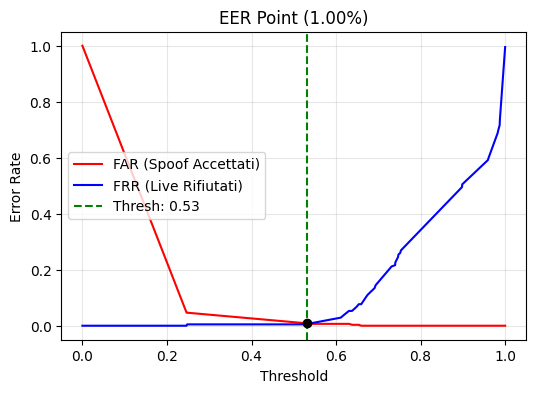


--- 1. Ricerca Soglia per FAR <= 0.5% ---
   >>> Soglia Trovata:       0.6379
   >>> FAR Effettivo:        0.33% (Target: 0.5%)
   >>> FRR Risultante:       5.29% (Live rifiutati)


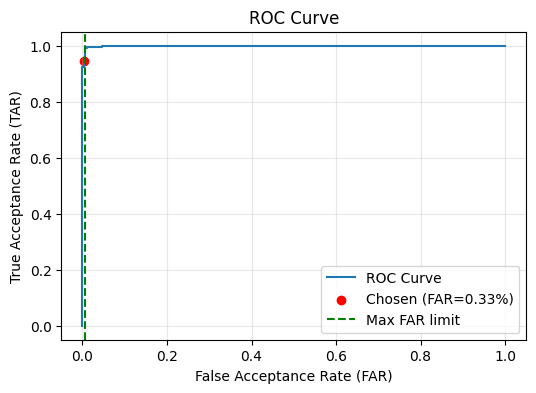

In [5]:
CONFIG = {
    'root_dir': '/content/drive/MyDrive/dataset_final_v1',
    'checkpoint_dir': '/content/drive/MyDrive/11/Consegna parziale/models/',
    'model_filename': 'best_weights_spoof_gr_11.pth',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'image_size': (160, 160),
    'batch_size': 16
}

print(f"--- Avvio Valutazione su {CONFIG['device']} ---")

val_dataset = SpoofingDataset(CONFIG['root_dir'], split='val', target_size=CONFIG['image_size'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

test_dataset = SpoofingDataset(CONFIG['root_dir'], split='test', target_size=CONFIG['image_size'])
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

model = SpoofingModel(pretrained=False)

evaluator = SpoofingEvaluator(model, CONFIG['device'], CONFIG)
evaluator.load_checkpoint(CONFIG['model_filename'])

threshold_eer = evaluator.find_threshold_eer(val_loader)
threshold_secure = evaluator.find_threshold_fixed_far(val_loader, target_far=0.005)

## **Validazione Finale su Dataset Privato**

In questa fase conclusiva, il sistema viene messo alla prova in uno scenario "Real-World" utilizzando il dataset **Spoof_finale**. Questo set contiene campioni inediti acquisiti dai soggetti del corso, rappresentando il banco di prova definitivo.

Viene utilizzata la **Soglia di Sicurezza** (`threshold_secure`) calcolata in precedenza per:
1.  **Analisi Errori:** Identificare quali specifici campioni reali o tentativi di spoofing riescono ancora a ingannare il sistema.
2.  **Report Finale:** Misurare le metriche di performance (FAR, FRR, HTER) su questi dati totalmente nuovi, verificando la robustezza del modello rispetto ai dati di training sintetici/pubblici.

[TEST] Originali -> Live: 182 | Spoof: 182
[TEST] Finali (dopo bilanciamento) -> Totale: 364

SOGLIA SCELTA PER IL TEST: 0.6379

--- 3. Analisi Dettagliata Errori (Soglia: 0.6379) ---
Falsi Positivi (Spoof passati): 1
   Score: 0.6538 | 14_1.jpg
Falsi Negativi (Live bloccati): 11
   Score: 0.5435 | real_1_MOV_f16.jpg
   Score: 0.6111 | real_2_mp4_f1.jpg
   Score: 0.5962 | real_1_MOV_f1.jpg
   Score: 0.6187 | real_1_MOV_f18.jpg
   Score: 0.6111 | real_2_mp4_f0.jpg
   Score: 0.2464 | Copia di subj_14_overexposed_00.jpg
   Score: 0.6225 | real_2_mp4_f22.jpg
   Score: 0.6106 | real_2_mp4_f2.jpg
   Score: 0.5202 | real_1_MOV_f0.jpg
   Score: 0.6225 | real_2_mp4_f21.jpg
   Score: 0.5989 | real_1_MOV_f2.jpg

--- 4. REPORT FINALE TEST SET (Soglia: 0.6379) ---
  METRICHE:
   - FAR (Sicurezza):  7.69%
   - FRR (Usabilità):  10.44%
   - HTER:             9.07%
   - ACCURACY:         90.93%
  DETTAGLIO:
   - Spoof Bloccati (TN): 168
   - Spoof Passati  (FP): 14 (ATTACCHI RIUSCITI)
   - Live Passat

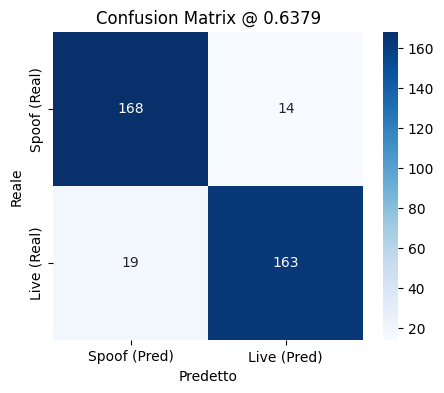

In [7]:
CONFIG = {
    'root_dir': '/content/drive/MyDrive/Spoof_finale',
    'checkpoint_dir': '/content/drive/MyDrive/11/Consegna parziale/models/',
    'model_filename': 'best_weights_spoof_gr_11.pth',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'image_size': (160, 160),
    'batch_size': 16
}

test_dataset = SpoofingDataset(CONFIG['root_dir'], split='test', target_size=CONFIG['image_size'])
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

FINAL_THRESHOLD = threshold_secure
print(f"\nSOGLIA SCELTA PER IL TEST: {FINAL_THRESHOLD:.4f}")

evaluator.analyze_errors(val_loader, FINAL_THRESHOLD)
evaluator.evaluate_test_set(test_loader, FINAL_THRESHOLD)